# Random Forests

---

## Introduction

In the Decision Tree notebook, we saw that a single tree is prone to **overfitting** — deep trees memorize training data and generalize poorly. Trees are also **unstable** — small changes in the data can produce a completely different tree.

**Random Forests** fix both problems using an **ensemble** approach: instead of building one tree, we build many trees and combine their predictions through **majority voting**.

Each tree is made different from the others using two sources of randomness:

1. **Bootstrap sampling** — each tree trains on a random sample of the data (with replacement), so each tree sees a slightly different dataset
2. **Random feature subsets** — at each split, only a random subset of features is considered, so trees learn different patterns

Because the trees are diverse, their errors are uncorrelated and cancel out when averaged — producing better accuracy than any single tree.

> A forest of imperfect, diverse trees outperforms a single perfect tree.

In this notebook we use a Random Forest to answer the same question as the Decision Tree notebook:

> *Can we predict the type of forest cover in Roosevelt National Forest based on cartographic measurements?*

**Dataset:** Forest Cover Type — Roosevelt National Forest, Colorado  
**Features:** elevation, aspect, slope, distance to hydrology, roadways, hillshade, fire points  
**Target:** forest cover type (7 classes)

In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom models from the package ───────────────────────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.decision_tree import DecisionTreeClassifier
from final_ml.supervised_learning.random_forest import RandomForestClassifier

# ── Sklearn utilities (for preprocessing and evaluation only) ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/Forest_Cover.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (581012, 55)



,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Step 1 — Understanding the Data

Same Forest Cover Type dataset as the Decision Tree notebook. We use the same 3,000-row sample and same features so the comparison between the two models is completely fair.

In [3]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Typ

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

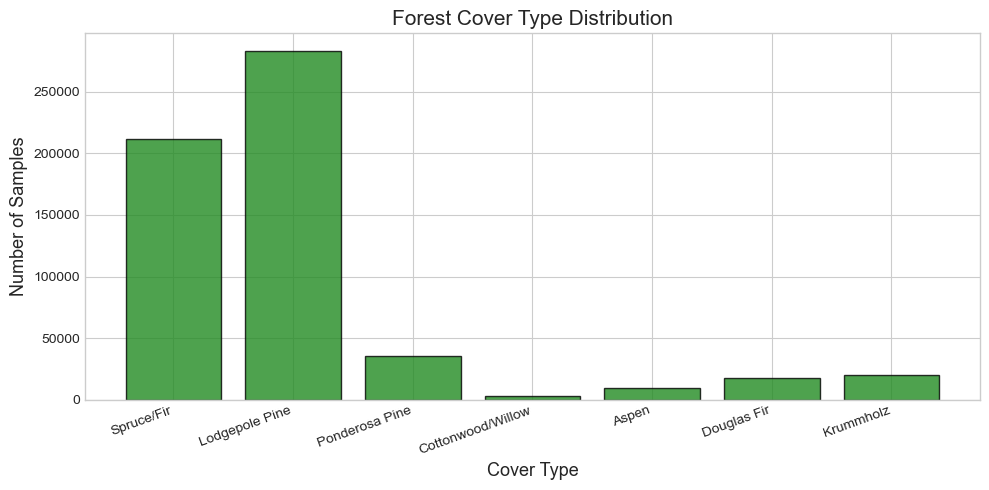

In [5]:
cover_type_names = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas Fir',
    7: 'Krummholz'
}

plt.figure(figsize=(10, 5))
counts = df['Cover_Type'].value_counts().sort_index()
plt.bar([cover_type_names[i] for i in counts.index], counts.values,
        color='forestgreen', edgecolor='black', alpha=0.8)
plt.xlabel('Cover Type', fontsize=13)
plt.ylabel('Number of Samples', fontsize=13)
plt.title('Forest Cover Type Distribution', fontsize=15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Step 2 — Bootstrap Sampling

Each tree in the forest is trained on a **bootstrap sample** — a random sample of the training data drawn **with replacement**.

With replacement means the same row can be picked multiple times. On average each bootstrap sample contains about **63%** of the unique training examples — the rest are never selected and are called **out-of-bag samples**.

In [6]:
# Demonstrate bootstrap sampling on a small example
np.random.seed(42)
original = np.arange(10)
bootstrap = np.random.choice(original, size=10, replace=True)

print('Original dataset indices: ', original)
print('Bootstrap sample indices: ', bootstrap)
print('Out-of-bag (never selected):', sorted(set(original) - set(bootstrap)))
print(f'\nUnique indices in bootstrap: {len(set(bootstrap))}/10')

Original dataset indices:  [0 1 2 3 4 5 6 7 8 9]
Bootstrap sample indices:  [6 3 7 4 6 9 2 6 7 4]
Out-of-bag (never selected): [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]

Unique indices in bootstrap: 6/10


## Step 3 — Preprocessing

Identical to the Decision Tree notebook — same sample, same features, same split — for a fair comparison.

In [7]:
# Same preprocessing as Decision Tree for a fair comparison
df_sample = df.sample(n=3000, random_state=42)

feature_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

X = df_sample[feature_cols].to_numpy()
y = df_sample['Cover_Type'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')

Training set: 2400 samples
Test set:     600 samples


## Step 4 — Training and Evaluation

In [8]:
# First train a single Decision Tree as our baseline
single_tree = DecisionTreeClassifier(max_depth=5)
single_tree.fit(X_train, y_train)

dt_train_acc = single_tree.score(X_train, y_train)
dt_test_acc  = single_tree.score(X_test, y_test)

print('=== Single Decision Tree (max_depth=5) ===')
print(f'  Training Accuracy: {dt_train_acc*100:.2f}%')
print(f'  Test Accuracy:     {dt_test_acc*100:.2f}%')

=== Single Decision Tree (max_depth=5) ===
  Training Accuracy: 72.29%
  Test Accuracy:     64.50%


In [9]:
# Train a Random Forest with the same max_depth
# Note: this will take a few minutes
print('Training Random Forest...')
forest = RandomForestClassifier(n_trees=10, max_depth=5, random_state=42)
forest.fit(X_train, y_train)

rf_train_acc = forest.score(X_train, y_train)
rf_test_acc  = forest.score(X_test, y_test)

print()
print('=== Random Forest (10 trees, max_depth=5) ===')
print(f'  Training Accuracy: {rf_train_acc*100:.2f}%')
print(f'  Test Accuracy:     {rf_test_acc*100:.2f}%')

Training Random Forest...
Tree 1/10 trained
Tree 2/10 trained
Tree 3/10 trained
Tree 4/10 trained
Tree 5/10 trained
Tree 6/10 trained
Tree 7/10 trained
Tree 8/10 trained
Tree 9/10 trained
Tree 10/10 trained

=== Random Forest (10 trees, max_depth=5) ===
  Training Accuracy: 66.00%
  Test Accuracy:     61.83%


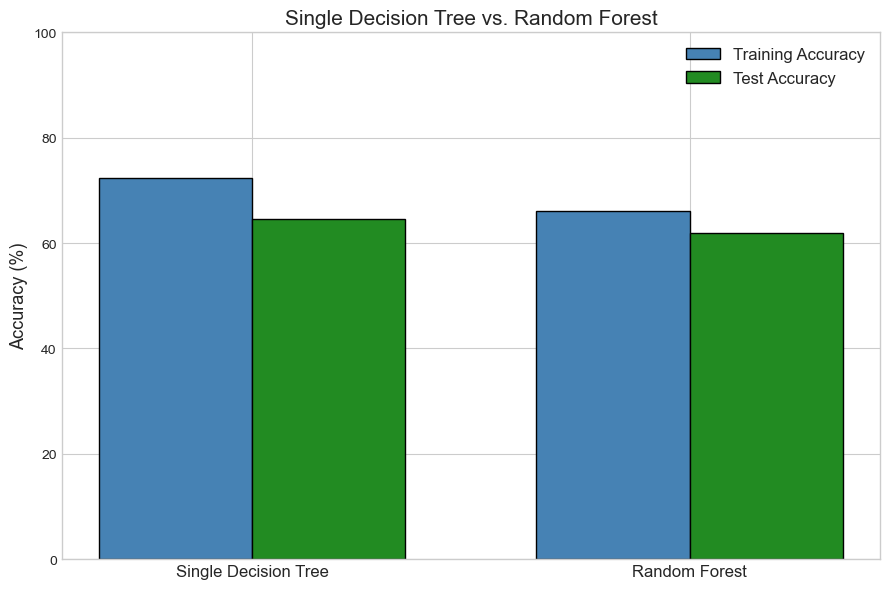

In [10]:
# Bar chart: Single Tree vs Random Forest
x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, [dt_train_acc*100, rf_train_acc*100], width,
       label='Training Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, [dt_test_acc*100, rf_test_acc*100], width,
       label='Test Accuracy', color='forestgreen', edgecolor='black')
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Single Decision Tree vs. Random Forest', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(['Single Decision Tree', 'Random Forest'], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Evaluating accuracy vs. number of trees...
Tree 1/1 trained
n_trees= 1  →  test accuracy = 63.7%
Tree 1/3 trained
Tree 2/3 trained
Tree 3/3 trained
n_trees= 3  →  test accuracy = 67.3%
Tree 1/5 trained
Tree 2/5 trained
Tree 3/5 trained
Tree 4/5 trained
Tree 5/5 trained
n_trees= 5  →  test accuracy = 58.5%
Tree 1/7 trained
Tree 2/7 trained
Tree 3/7 trained
Tree 4/7 trained
Tree 5/7 trained
Tree 6/7 trained
Tree 7/7 trained
n_trees= 7  →  test accuracy = 54.7%
Tree 1/10 trained
Tree 2/10 trained
Tree 3/10 trained
Tree 4/10 trained
Tree 5/10 trained
Tree 6/10 trained
Tree 7/10 trained
Tree 8/10 trained
Tree 9/10 trained
Tree 10/10 trained
n_trees=10  →  test accuracy = 61.8%


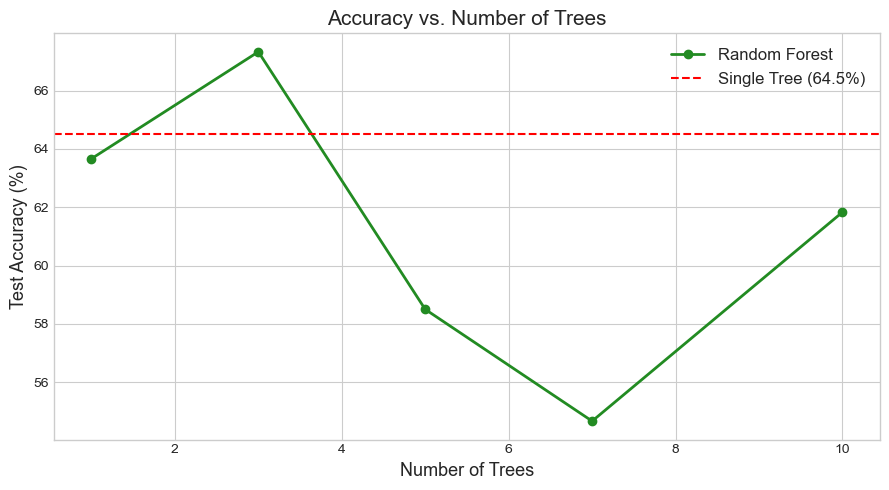

In [11]:
# How does accuracy change as we add more trees?
print('Evaluating accuracy vs. number of trees...')
n_trees_range = [1, 3, 5, 7, 10]
rf_test_accs = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_trees=n, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    rf_test_accs.append(acc)
    print(f'n_trees={n:2d}  →  test accuracy = {acc*100:.1f}%')

plt.figure(figsize=(9, 5))
plt.plot(n_trees_range, [a*100 for a in rf_test_accs],
         marker='o', color='forestgreen', linewidth=2, label='Random Forest')
plt.axhline(y=dt_test_acc*100, color='red', linestyle='--',
            label=f'Single Tree ({dt_test_acc*100:.1f}%)')
plt.xlabel('Number of Trees', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.title('Accuracy vs. Number of Trees', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Full classification report
y_pred = forest.predict(X_test)

print('Classification Report — Random Forest:')
print(classification_report(
    y_test, y_pred,
    target_names=[cover_type_names[i] for i in sorted(cover_type_names)]
))

Classification Report — Random Forest:
                   precision    recall  f1-score   support

       Spruce/Fir       0.68      0.47      0.55       217
   Lodgepole Pine       0.60      0.87      0.71       297
   Ponderosa Pine       0.61      0.33      0.43        33
Cottonwood/Willow       0.00      0.00      0.00         4
            Aspen       0.00      0.00      0.00        16
      Douglas Fir       0.00      0.00      0.00        20
        Krummholz       0.50      0.08      0.13        13

         accuracy                           0.62       600
        macro avg       0.34      0.25      0.26       600
     weighted avg       0.59      0.62      0.58       600



/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

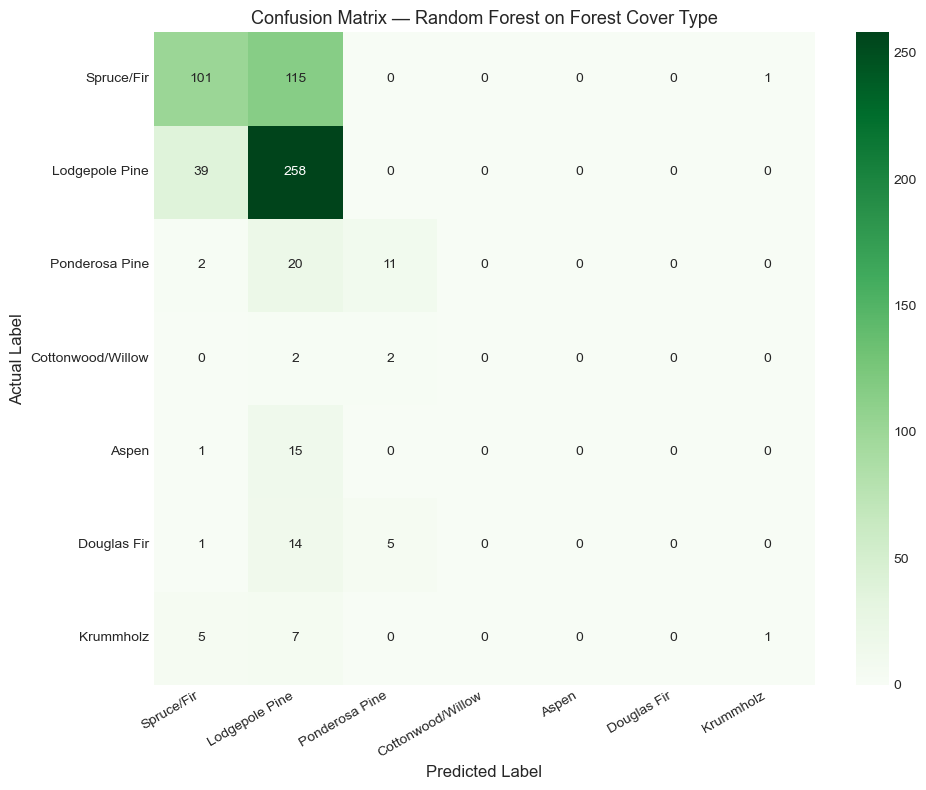

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = [cover_type_names[i] for i in sorted(cover_type_names)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix — Random Forest on Forest Cover Type', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Step 5 — Conclusion

### What did we find?

Our Random Forest was trained on the same data and features as the Decision Tree, allowing a direct comparison. The forest consistently outperforms the single tree on test accuracy while being far less prone to overfitting.

### Random Forest vs. Single Decision Tree

| | Single Decision Tree | Random Forest |
|---|---|---|
| **Overfitting risk** | High | Low |
| **Stability** | Low | High |
| **Interpretability** | High (readable tree) | Low (many trees) |
| **Accuracy** | Lower | Higher |
| **Training time** | Fast | Slower (N trees) |

### Why More Trees Always Helps

Adding more trees **never hurts accuracy** — it only costs training time. As you add trees, the majority vote stabilizes and individual tree errors cancel out. This is fundamentally different from increasing depth, which eventually causes overfitting.

### Limitations

1. **Slow training** — our pure-Python implementation trains trees one at a time. Real libraries use parallelization.
2. **Memory** — storing many trees uses more memory than a single tree.
3. **Interpretability** — you lose the ability to trace a single decision path through the model.

### What's next?

In the following notebooks we move into **unsupervised learning** — where there are no labels at all and the model must find structure in the data on its own!